<a href="https://colab.research.google.com/github/ysacodes/E-comm-Customer-Churn-Analysis-Prediction/blob/main/e_comm_full_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mount, Import libraries, Load dataset

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer


df = pd.read_excel('/content/drive/MyDrive/Hi/E Commerce Dataset.xlsx', sheet_name='E Comm')

# EDA

In [3]:
print(df.head())
print(df.tail())
print(df.shape)
print(df.dtypes)

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN                Phone         1              8.0   
2       50003      1     NaN                Phone         1             30.0   
3       50004      1     0.0                Phone         3             15.0   
4       50005      1     0.0                Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male             2.0                         4   
4                   CC    Male             NaN                         3   

     PreferedOrderCat  SatisfactionScore MaritalStatus  Number

In [4]:
print(df.describe().transpose())

                              count          mean          std      min  \
CustomerID                   5630.0  52815.500000  1625.385339  50001.0   
Churn                        5630.0      0.168384     0.374240      0.0   
Tenure                       5366.0     10.189899     8.557241      0.0   
CityTier                     5630.0      1.654707     0.915389      1.0   
WarehouseToHome              5379.0     15.639896     8.531475      5.0   
HourSpendOnApp               5375.0      2.931535     0.721926      0.0   
NumberOfDeviceRegistered     5630.0      3.688988     1.023999      1.0   
SatisfactionScore            5630.0      3.066785     1.380194      1.0   
NumberOfAddress              5630.0      4.214032     2.583586      1.0   
Complain                     5630.0      0.284902     0.451408      0.0   
OrderAmountHikeFromlastYear  5365.0     15.707922     3.675485     11.0   
CouponUsed                   5374.0      1.751023     1.894621      0.0   
OrderCount               

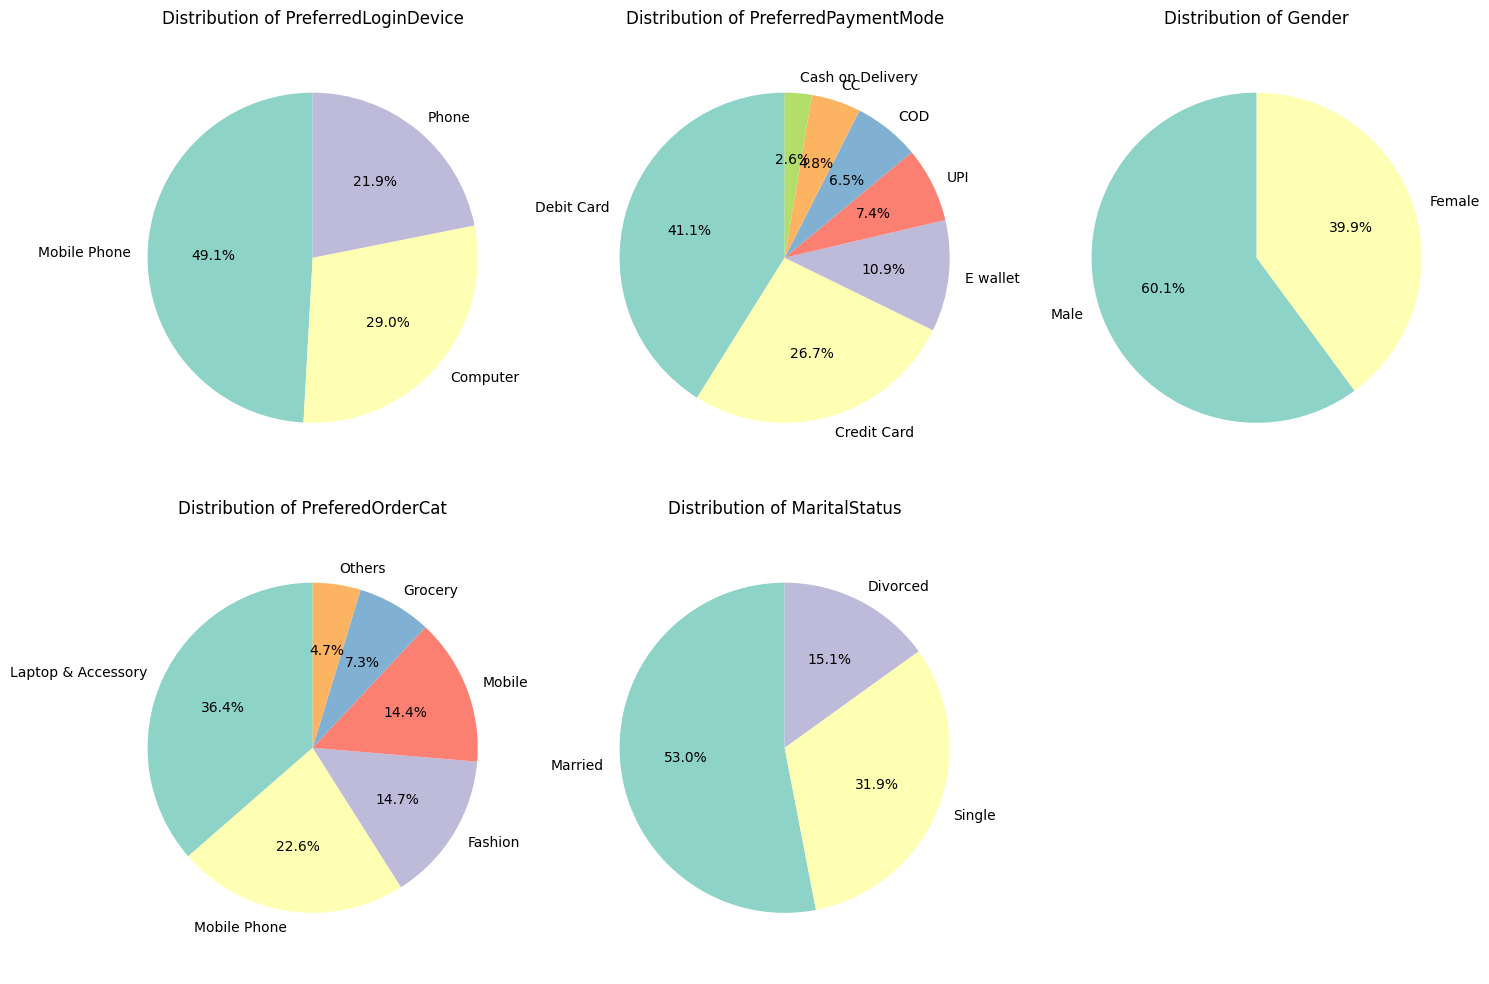

In [5]:
# Distribution of each categorical feature.
# Checked here to spot severe class imbalance or single-category columns
# before they're used as predictors later on.
cat_cols = [c for c in df.columns if df[c].dtype == 'object']
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
                startangle=90, colors=plt.cm.Set3.colors)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].axis('equal')

for j in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [6]:
# Duplicate check
print("Duplicate CustomerIDs:", df.duplicated(subset=['CustomerID']).sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate CustomerIDs: 0
Fully duplicate rows: 0


In [7]:
# Missing values per column
print(df.isnull().sum())

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64


# Split dataset into train and test

In [8]:
X = df.drop(columns=['Churn'])
y = df['Churn']

from sklearn.model_selection import train_test_split

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the splits
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Testing features shape: {y_test.shape}")

Training features shape: (4504, 19)
Testing features shape: (1126, 19)
Testing features shape: (1126,)


In [9]:
print('--- Consolidating categories on X_train and X_test ---')

# 1. Consolidate PreferredLoginDevice: Merge Mobile Phone and Phone
X_train['PreferredLoginDevice'] = X_train['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
X_test['PreferredLoginDevice'] = X_test['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})
print("Consolidated 'PreferredLoginDevice' categories for X_train and X_test.")

# 2. Consolidate PreferredPaymentMode: Merge CC and Credit Card. Cash on Delivery and COD.
X_train['PreferredPaymentMode'] = X_train['PreferredPaymentMode'].replace({'CC': 'Credit Card', 'COD': 'Cash on Delivery'})
X_test['PreferredPaymentMode'] = X_test['PreferredPaymentMode'].replace({'CC': 'Credit Card', 'COD': 'Cash on Delivery'})
print("Consolidated 'PreferredPaymentMode' categories for X_train and X_test.")

# 3. Consolidate PreferedOrderCat: Merge Mobile Phone and Mobile.
X_train['PreferedOrderCat'] = X_train['PreferedOrderCat'].replace({'Mobile Phone': 'Mobile'})
X_test['PreferedOrderCat'] = X_test['PreferedOrderCat'].replace({'Mobile Phone': 'Mobile'})
print("Consolidated 'PreferedOrderCat' categories for X_train and X_test.")

print('\n--- Updated value counts after consolidation (X_train) ---')
print("PreferredLoginDevice:\n", X_train['PreferredLoginDevice'].value_counts())
print("\nPreferredPaymentMode:\n", X_train['PreferredPaymentMode'].value_counts())
print("\nPreferedOrderCat:\n", X_train['PreferedOrderCat'].value_counts())

print('\n--- Updated value counts after consolidation (X_test) ---')
print("PreferredLoginDevice:\n", X_test['PreferredLoginDevice'].value_counts())
print("\nPreferredPaymentMode:\n", X_test['PreferredPaymentMode'].value_counts())
print("\nPreferedOrderCat:\n", X_test['PreferedOrderCat'].value_counts())

--- Consolidating categories on X_train and X_test ---
Consolidated 'PreferredLoginDevice' categories for X_train and X_test.
Consolidated 'PreferredPaymentMode' categories for X_train and X_test.
Consolidated 'PreferedOrderCat' categories for X_train and X_test.

--- Updated value counts after consolidation (X_train) ---
PreferredLoginDevice:
 PreferredLoginDevice
Mobile Phone    3191
Computer        1313
Name: count, dtype: int64

PreferredPaymentMode:
 PreferredPaymentMode
Debit Card          1845
Credit Card         1415
E wallet             488
Cash on Delivery     420
UPI                  336
Name: count, dtype: int64

PreferedOrderCat:
 PreferedOrderCat
Mobile                1674
Laptop & Accessory    1644
Fashion                643
Grocery                330
Others                 213
Name: count, dtype: int64

--- Updated value counts after consolidation (X_test) ---
PreferredLoginDevice:
 PreferredLoginDevice
Mobile Phone    805
Computer        321
Name: count, dtype: int64



# Handling Missing Values

In [10]:
def print_missing_summary(data, name):
    print(f"Missing values summary for {name}")
    missing_summary = data.isnull().sum()
    missing_summary = missing_summary[missing_summary > 0].to_frame('missing_count')
    if not missing_summary.empty:
        missing_summary['missing_pct'] = (missing_summary['missing_count'] / len(data) * 100).round(2)
        missing_summary['dtype'] = data.loc[:, missing_summary.index].dtypes.values
    print(missing_summary)
    print("\n")

print_missing_summary(X_train, 'X_train')
print_missing_summary(X_test, 'X_test')

Missing values summary for X_train
                             missing_count  missing_pct    dtype
Tenure                                 216         4.80  float64
WarehouseToHome                        203         4.51  float64
HourSpendOnApp                         206         4.57  float64
OrderAmountHikeFromlastYear            216         4.80  float64
CouponUsed                             203         4.51  float64
OrderCount                             207         4.60  float64
DaySinceLastOrder                      230         5.11  float64


Missing values summary for X_test
                             missing_count  missing_pct    dtype
Tenure                                  48         4.26  float64
WarehouseToHome                         48         4.26  float64
HourSpendOnApp                          49         4.35  float64
OrderAmountHikeFromlastYear             49         4.35  float64
CouponUsed                              53         4.71  float64
OrderCount         

In [11]:
from sklearn.impute import SimpleImputer

# 1. Separate our column types (excluding CustomerID from both)
nominal_cols = ['Gender', 'PreferredPaymentMode', 'PreferredLoginDevice', 'PreferedOrderCat', 'MaritalStatus']
numeric_cols = [col for col in X_train.columns if col not in nominal_cols and col != 'CustomerID']

# ==========================================
# STEP 1: IMPUTE NUMERICAL DATA (MEDIAN IMPUTATION)
# ==========================================
print("--- 1. Applying Median Imputation to Numerical Columns First ---")

# Initialize the SimpleImputer with median strategy
imputer = SimpleImputer(strategy='median')

# Fit on X_train's numeric columns, then transform both Train and Test
X_train_imputed_num = imputer.fit_transform(X_train[numeric_cols])
X_test_imputed_num = imputer.transform(X_test[numeric_cols])

# Safely put the imputed numbers back into the dataframes
X_train.loc[:, numeric_cols] = X_train_imputed_num
X_test.loc[:, numeric_cols] = X_test_imputed_num

print(f"Missing values in X_train after Median Imputation: {X_train.isnull().sum().sum()}")
print(f"Missing values in X_test after Median Imputation:  {X_test.isnull().sum().sum()}")

--- 1. Applying Median Imputation to Numerical Columns First ---
Missing values in X_train after Median Imputation: 0
Missing values in X_test after Median Imputation:  0


# Encode

In [12]:
# Apply one-hot encoding
X_train = pd.get_dummies(X_train, columns=nominal_cols, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=nominal_cols, drop_first=True, dtype=int)

# This ensures X_test has the exact same columns as X_train.
# If X_test is missing a category that was in X_train, this fills it with 0s so .predict() won't crash later!
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("X_train head after Imputation & OHE:")
print(X_train.head(3))

print(f"\nFinal Shape of X_train: {X_train.shape}")
print(f"Final Shape of X_test:  {X_test.shape}")

X_train head after Imputation & OHE:
      CustomerID  Tenure  CityTier  WarehouseToHome  HourSpendOnApp  \
4478       54479     1.0         1             12.0             3.0   
3685       53686    17.0         1             13.0             4.0   
731        50732     0.0         1              9.0             3.0   

      NumberOfDeviceRegistered  SatisfactionScore  NumberOfAddress  Complain  \
4478                         4                  4                3         1   
3685                         5                  3                3         1   
731                          4                  3                2         0   

      OrderAmountHikeFromlastYear  ...  PreferredPaymentMode_Debit Card  \
4478                         13.0  ...                                1   
3685                         15.0  ...                                0   
731                          12.0  ...                                1   

      PreferredPaymentMode_E wallet  PreferredPaymentMod

# Handling Noisy Values

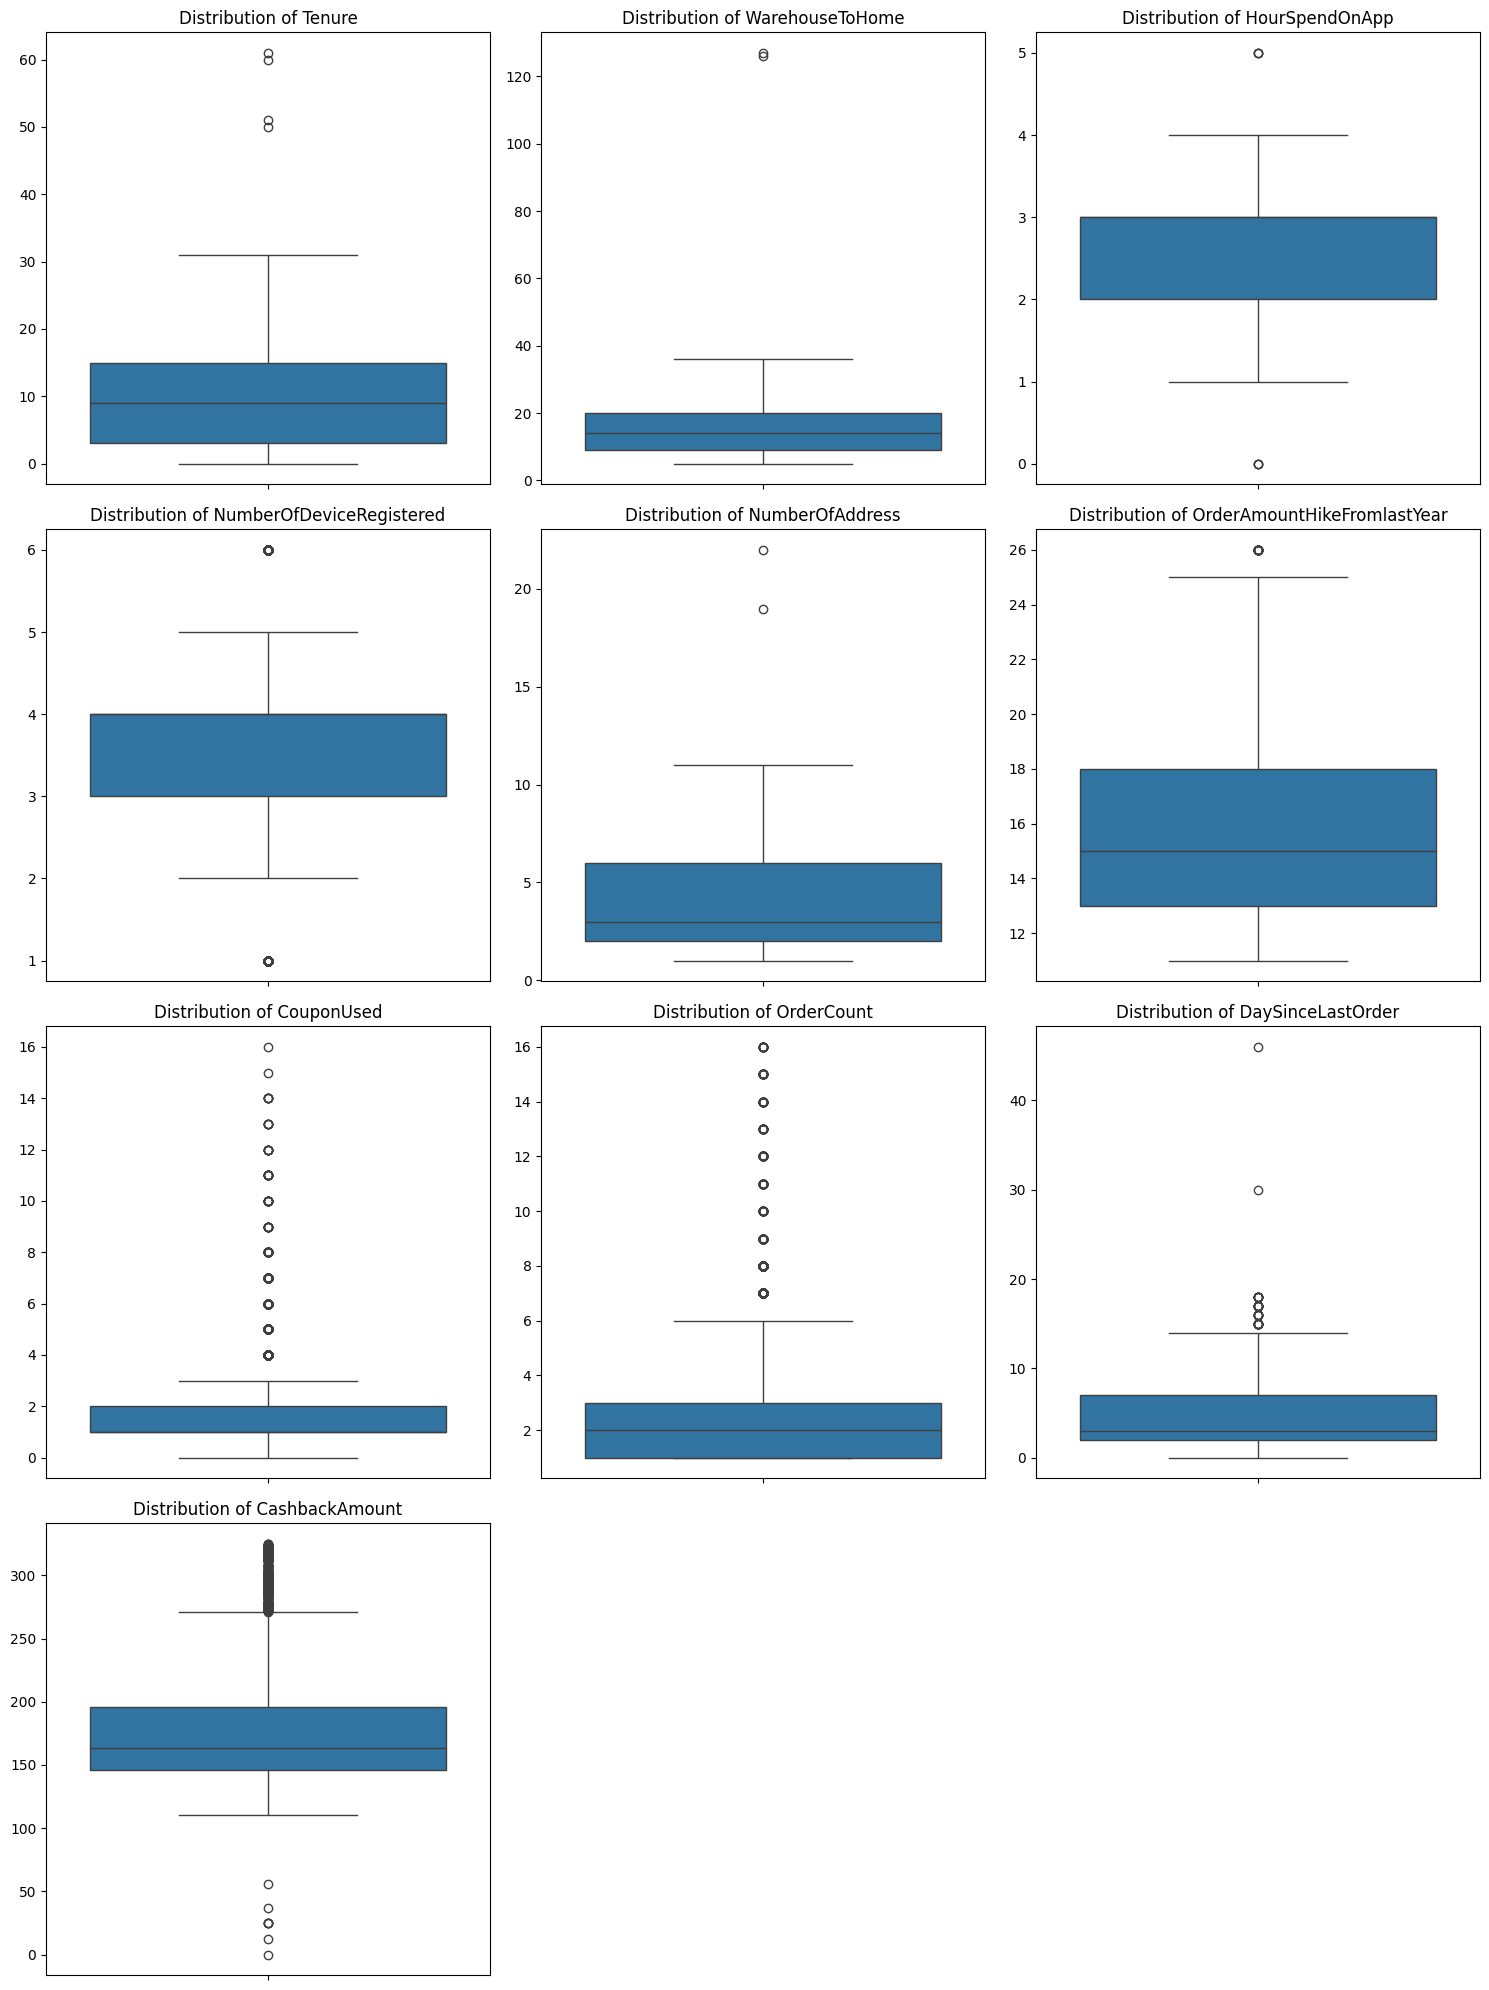

In [13]:
numeric_cols = X_train.select_dtypes(include='number')

exclude_from_boxplot = ['CustomerID', 'Complain', 'CityTier', 'SatisfactionScore',
    'Gender_Male','PreferredPaymentMode_Credit Card','PreferredPaymentMode_Debit Card','PreferredPaymentMode_E wallet',
    'PreferredPaymentMode_UPI','PreferredLoginDevice_Mobile Phone','PreferedOrderCat_Grocery',
    'PreferedOrderCat_Laptop & Accessory','PreferedOrderCat_Mobile','PreferedOrderCat_Others',
    'MaritalStatus_Single','MaritalStatus_Married']

# Filter out the excluded columns from the numeric_cols list
numeric_cols = [col for col in numeric_cols if col not in exclude_from_boxplot]

# Calculate the number of rows and columns needed for the subplots
num_cols = len(numeric_cols)
num_rows = math.ceil(num_cols / 3)  # Aim for 3 columns per row

fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(15, num_rows * 5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(y=X_train[col], ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_ylabel('') # Remove y-label for cleaner look, title is sufficient

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

According to domain knowledge, the only real outliers are in columns WarehouseToHome and NumberOfAddresses.   

For WarehouseToHome, since most observations are about <20km, it doesnt make much sense to why we see a 120km value, however, it is still a possibility, so instead of removing, Winsorization is chosen to be applied instead.  

For NumberOfAddresses, I've decided to drop the outliers.

In [14]:
!pip install feature_engine

In [15]:
from feature_engine.outliers import Winsorizer

columns_for_winsorization = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered',
                             'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
                             'DaySinceLastOrder', 'CashbackAmount']
columns_for_dropping = ['NumberOfAddress']

print("Handling WarehouseToHome and other numerical columns (Winsorization using Winsorizer)")
# Initialize Winsorizer for the specified columns
# capping_method='iqr' uses the IQR method (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
# tail='both' caps both lower and upper tails
# fold=1.5 is the multiplier for the IQR
winsorizer = Winsorizer(capping_method='iqr', tail='both', fold=1.5, variables=columns_for_winsorization)

# Fit the winsorizer on X_train
winsorizer.fit(X_train)

# Transform both X_train and X_test
X_train = winsorizer.transform(X_train)
X_test = winsorizer.transform(X_test)

print(f"Values in X_train for {columns_for_winsorization} have been Winsorized using Winsorizer.")
print(f"Values in X_test for {columns_for_winsorization} have been Winsorized using X_train's bounds.")

print("\nHandling NumberOfAddress (Dropping Outliers)")
# Identify and drop outliers
for col in columns_for_dropping:
    # Calculate Q1, Q3, IQR based on X_train for consistency and to prevent data leakage
    Q1_train = X_train[col].quantile(0.25)
    Q3_train = X_train[col].quantile(0.75)
    IQR_train = Q3_train - Q1_train
    lower_bound_train = Q1_train - 1.5 * IQR_train
    upper_bound_train = Q3_train + 1.5 * IQR_train

    # Identify indices of outliers in X_train for the current column
    outlier_indices_train = X_train[(X_train[col] < lower_bound_train) | (X_train[col] > upper_bound_train)].index
    outliers_count_train = len(outlier_indices_train)
    print(f"Number of outliers detected in X_train '{col}' for dropping: {outlier_indices_train.shape[0]}")

    if not outlier_indices_train.empty:
        original_rows_train = X_train.shape[0]
        X_train = X_train.drop(outlier_indices_train)
        rows_dropped_train = original_rows_train - X_train.shape[0]
        print(f"Dropped {rows_dropped_train} rows containing outliers from X_train '{col}'.")
    else:
        print(f"No rows were dropped from X_train as no outliers were found in '{col}'.")

    # For dropping, we only modify X_train and then align y_train
    # X_test remains unchanged for dropping, as dropping rows in test would make it inconsistent with y_test
    print(f"X_test remains unchanged for '{col}' outliers. Original shape: {X_test.shape}")

y_train = y_train.loc[X_train.index]

print(f"\nNew X_train DataFrame shape: {X_train.shape}")
print(f"New X_test DataFrame shape: {X_test.shape}")

# Display summary statistics to confirm changes for X_train
print("\nSummary statistics for X_train after outlier handling (Winsorized/Dropped columns):")
print(X_train[columns_for_winsorization + columns_for_dropping].describe())

# Display summary statistics to confirm changes for X_test
print("\nSummary statistics for X_test after outlier handling (Winsorized columns):")
print(X_test[columns_for_winsorization + columns_for_dropping].describe())

Handling WarehouseToHome and other numerical columns (Winsorization using Winsorizer)
Values in X_train for ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'] have been Winsorized using Winsorizer.
Values in X_test for ['Tenure', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount'] have been Winsorized using X_train's bounds.

Handling NumberOfAddress (Dropping Outliers)
Number of outliers detected in X_train 'NumberOfAddress' for dropping: 2
Dropped 2 rows containing outliers from X_train 'NumberOfAddress'.
X_test remains unchanged for 'NumberOfAddress' outliers. Original shape: (1126, 26)

New X_train DataFrame shape: (4502, 26)
New X_test DataFrame shape: (1126, 26)

Summary statistics for X_train after outlier handling (Winsorized/Dropped columns):
    

# Feature Engineering

In [16]:
# 1. Calculate new features for X_train and X_test
print("\n--- Creating new features for X_train and X_test ---")

for df_target in [X_train, X_test]:
    # Cashback per Order
    df_target['Cashback_per_Order'] = df_target['CashbackAmount'] / df_target['OrderCount']
    # Coupons per Order
    df_target['Coupons_per_Order'] = df_target['CouponUsed'] / df_target['OrderCount']
    # Devices per Address
    df_target['Devices_per_Address'] = df_target['NumberOfDeviceRegistered'] / df_target['NumberOfAddress']
    # Orders per Tenure Month
    df_target['Orders_per_Tenure_Month'] = df_target['OrderCount'] / df_target['Tenure']

    # Handle division by zero / NaNs in new features
    for new_col in ['Cashback_per_Order', 'Coupons_per_Order', 'Devices_per_Address', 'Orders_per_Tenure_Month']:
        df_target[new_col] = df_target[new_col].replace([np.inf, -np.inf], np.nan)
        df_target[new_col] = df_target[new_col].fillna(0)
    print(f"Created and cleaned new features for {df_target.name if hasattr(df_target, 'name') else 'DataFrame'}")

print("\nNew X_train DataFrame head with new features:")
print(X_train[['Cashback_per_Order', 'Coupons_per_Order', 'Devices_per_Address', 'Orders_per_Tenure_Month']].head())

print("\nNew X_test DataFrame head with new features:")
print(X_test[['Cashback_per_Order', 'Coupons_per_Order', 'Devices_per_Address', 'Orders_per_Tenure_Month']].head())


--- Creating new features for X_train and X_test ---
Created and cleaned new features for DataFrame
Created and cleaned new features for DataFrame

New X_train DataFrame head with new features:
      Cashback_per_Order  Coupons_per_Order  Devices_per_Address  \
4478              74.890                0.5             1.333333   
3685              82.905                1.0             1.666667   
731              130.330                0.0             2.000000   
291              117.020                1.0             1.500000   
184              148.210                0.0             3.000000   

      Orders_per_Tenure_Month  
4478                 2.000000  
3685                 0.117647  
731                  0.000000  
291                  0.111111  
184                  0.250000  

New X_test DataFrame head with new features:
      Cashback_per_Order  Coupons_per_Order  Devices_per_Address  \
4331              74.125              1.000             2.750000   
1988             152.3

# Feature Selection

In [17]:
pip install phik

interval columns not set, guessing: ['Tenure', 'CityTier', 'WarehouseToHome', 'HourSpendOnApp', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount', 'DaySinceLastOrder', 'CashbackAmount', 'Gender_Male', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_Debit Card', 'PreferredPaymentMode_E wallet', 'PreferredPaymentMode_UPI', 'PreferredLoginDevice_Mobile Phone', 'PreferedOrderCat_Grocery', 'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile', 'PreferedOrderCat_Others', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Cashback_per_Order', 'Coupons_per_Order', 'Devices_per_Address', 'Orders_per_Tenure_Month', 'Churn']


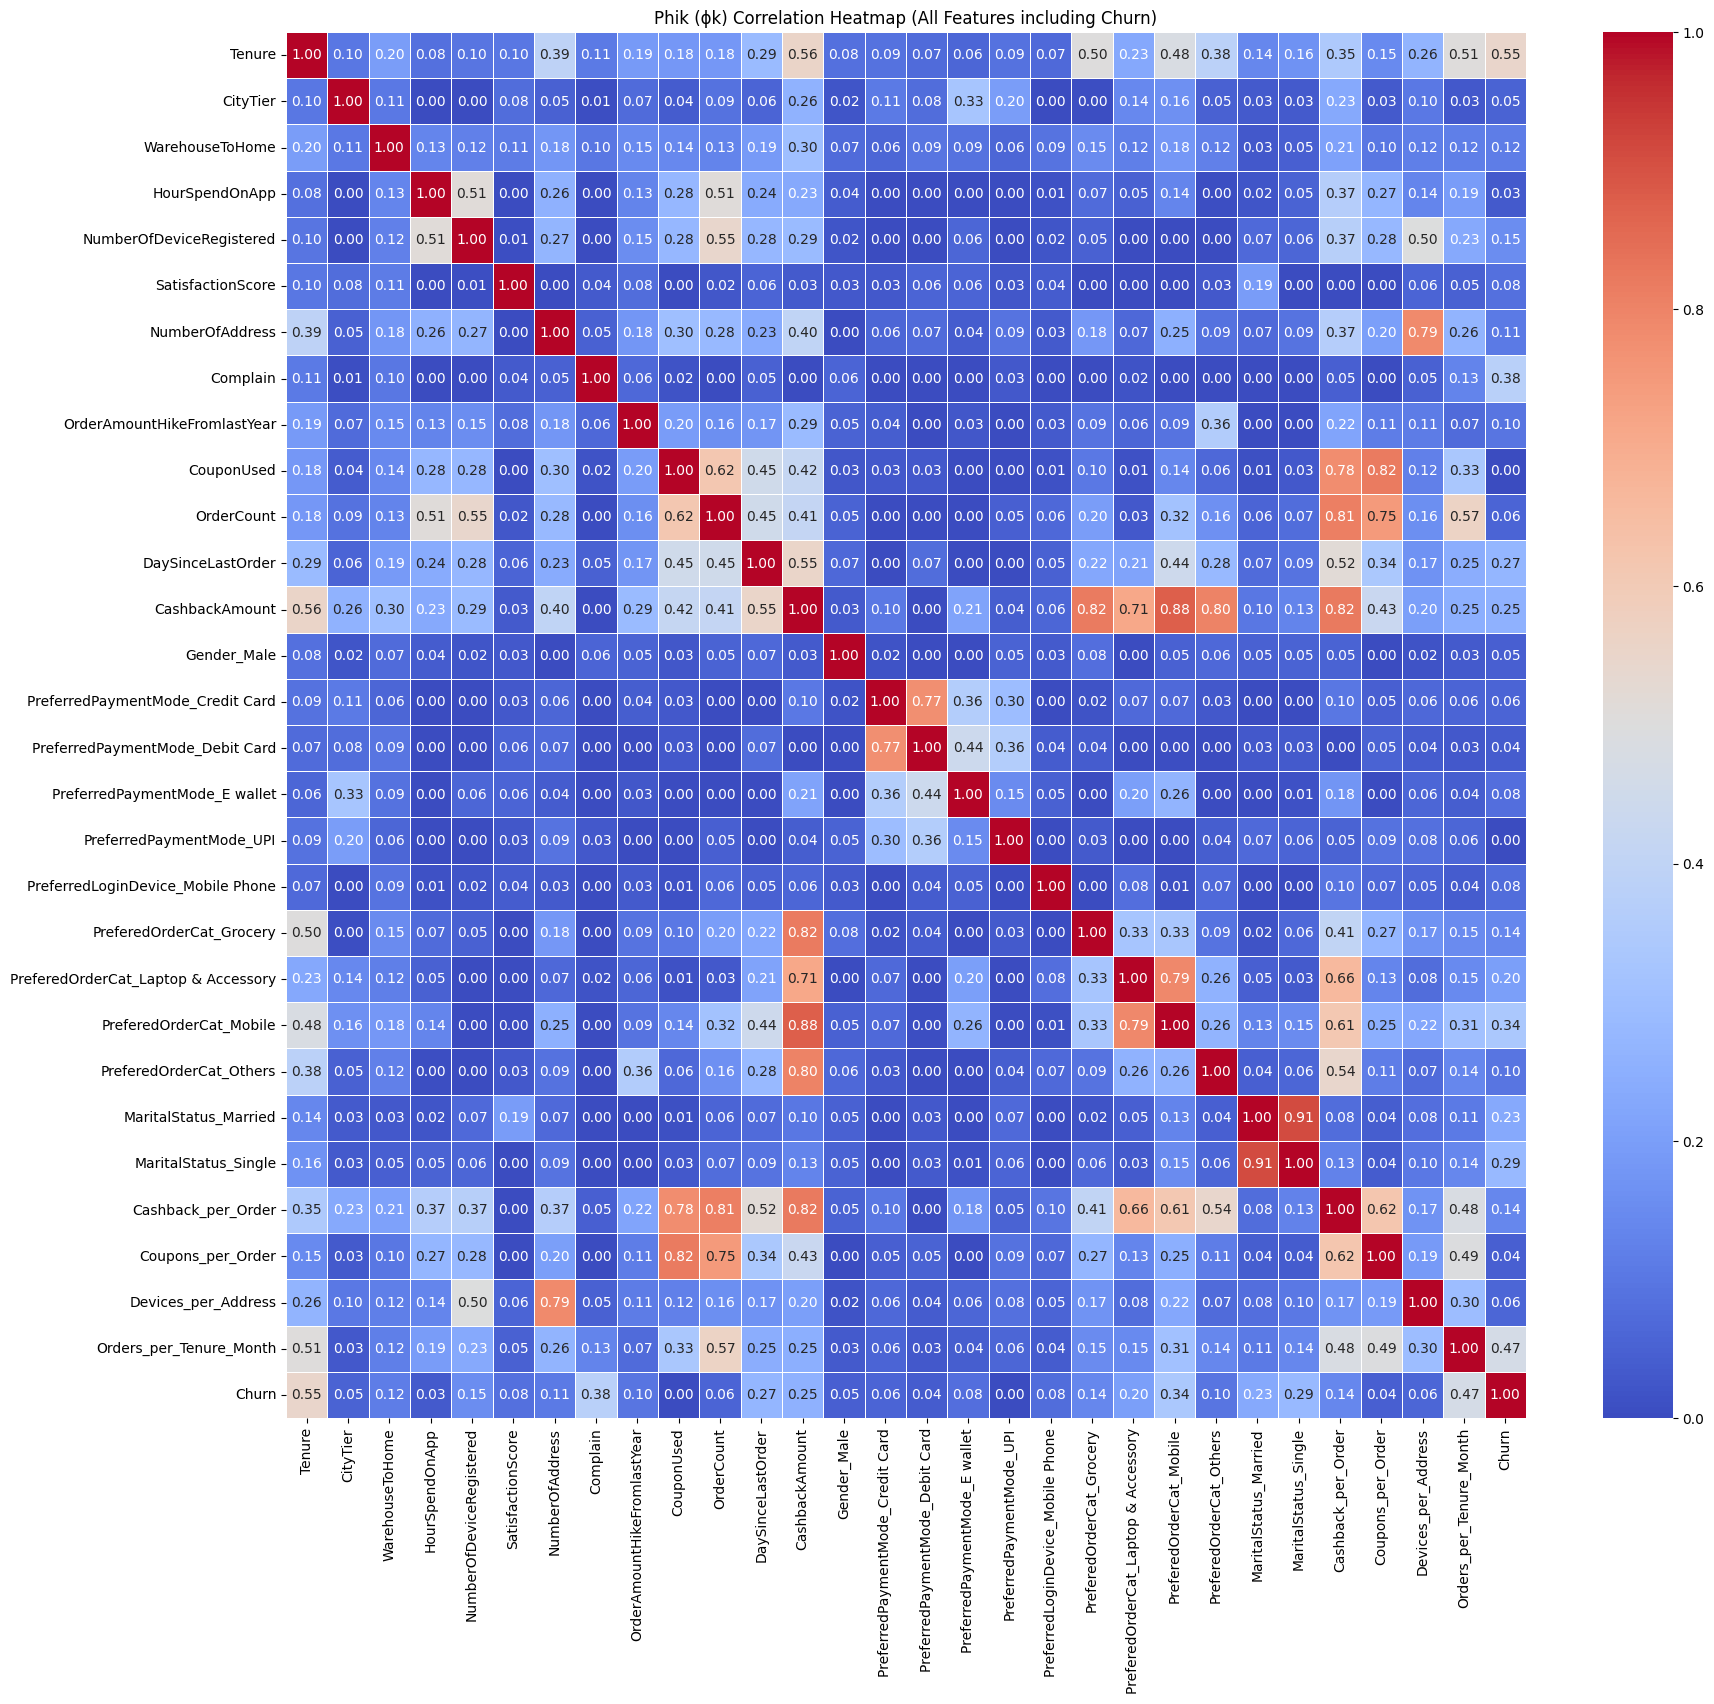

In [18]:
import phik
from phik.phik import phik_matrix

# Combine X_train and y_train for Phik correlation calculation
df_combined = pd.concat([X_train.drop(columns=['CustomerID'], errors='ignore'), y_train], axis=1)

# Calculate the Phik correlation matrix
# The phik_matrix function automatically identifies and handles numerical and categorical columns
phik_corr = df_combined.phik_matrix()

# Plot the Phik correlation heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(phik_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Phik (ϕk) Correlation Heatmap (All Features including Churn)')
plt.show()

In [19]:
from sklearn.ensemble import RandomForestClassifier

X_full = X_train.copy()
y_full = y_train.copy()

# Align y_full to X_full's index
y_full = y_full.loc[X_full.index]

X_full = X_full.drop(columns=['CustomerID'], errors='ignore')

print("\n" + "="*80)
print("FEATURE EVALUATION SUMMARY CHECKLIST")
print("="*80)

# 1. Compute Linear Correlation against Churn (Not sorted yet to maintain clean logic)
correlations = X_full.corrwith(y_full).abs()

# 2. Train a Tree-Based Model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_full, y_full)

# 3. Compile Metric Dataframe (SAFELY ALIGNED)
feature_assessment = pd.DataFrame({
    'Linear_Correlation': correlations,
    'Tree_Importance': pd.Series(rf.feature_importances_, index=X_full.columns)
}).sort_values(by='Tree_Importance', ascending=False)

# Define thresholds
corr_threshold = 0.10
importance_threshold = feature_assessment['Tree_Importance'].median()

checklist_results = []

for feature, row in feature_assessment.iterrows():
    corr = row['Linear_Correlation']
    imp = row['Tree_Importance']

    is_low_corr = corr < corr_threshold
    is_low_imp = imp < importance_threshold

    if is_low_corr and is_low_imp:
        scenario = "Scenario 1"
        action = "❌ Drop"
        why = "It doesn't matter linearly, and tree algorithms aren't finding any useful combinations either."
    elif is_low_corr and not is_low_imp:
        scenario = "Scenario 2"
        action = "Keep"
        why = "The tree is leveraging it via sequential splits (interactions)."
    else:
        scenario = "Baseline Pass"
        action = "Keep & Test"
        why = "Strong linear correlation or highly notable component matrix metrics."

    checklist_results.append({
        'Feature': feature,
        'Correlation': round(corr, 4),
        'Tree Importance': round(imp, 4),
        'Scenario Match': scenario,
        'Action Status': action,
        'Reasoning Details': why
    })

df_checklist = pd.DataFrame(checklist_results)
print(df_checklist.to_markdown(index=False))
print("="*80)


FEATURE EVALUATION SUMMARY CHECKLIST
| Feature                             |   Correlation |   Tree Importance | Scenario Match   | Action Status   | Reasoning Details                                                                              |
|:------------------------------------|--------------:|------------------:|:-----------------|:----------------|:-----------------------------------------------------------------------------------------------|
| Tenure                              |        0.3413 |            0.1528 | Baseline Pass    | Keep & Test     | Strong linear correlation or highly notable component matrix metrics.                          |
| Orders_per_Tenure_Month             |        0.2794 |            0.0971 | Baseline Pass    | Keep & Test     | Strong linear correlation or highly notable component matrix metrics.                          |
| CashbackAmount                      |        0.1717 |            0.085  | Baseline Pass    | Keep & Test     | Strong li

In [20]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# Acknowledge that X_train and X_test have already been reduced to 22 features.
# To apply SelectFromModel dynamically to the *current* dataset,
# we need to re-fit the RandomForestClassifier on this current X_train.

# 1. Instantiate and fit a NEW RandomForestClassifier on the current X_train
#    This ensures the model expects the correct number of features (22).
#    Using the same parameters as the original 'rf' for consistency in model type.
rf_current = RandomForestClassifier(n_estimators=100, random_state=42)
rf_current.fit(X_train, y_train) # Fit on the current X_train with 22 features

# 2. Recalculate importance_threshold based on the current rf_current model
#    The median importance is still a reasonable heuristic for the threshold.
importance_threshold_current = pd.Series(rf_current.feature_importances_, index=X_train.columns).median()

# 3. Initialize SelectFromModel using the newly fitted RandomForestClassifier
#    and the recalculated threshold.
sfm = SelectFromModel(rf_current, threshold=importance_threshold_current, prefit=True)

# Fit sfm itself to set its internal state, even with prefit=True
sfm.fit(X_train, y_train)

# Transform X_train and X_test to select features
X_train_selected = sfm.transform(X_train)
X_test_selected = sfm.transform(X_test)

# Get the names of the selected features
selected_features = sfm.get_feature_names_out(X_train.columns)

# Convert the transformed arrays back to DataFrames with column names
X_train = pd.DataFrame(X_train_selected, columns=selected_features, index=X_train.index)
X_test = pd.DataFrame(X_test_selected, columns=selected_features, index=X_test.index)

print(f"Features selected dynamically using SelectFromModel (threshold={importance_threshold_current:.4f}).")
print(f"New X_train shape: {X_train.shape}")
print("Remaining features in X_train:", X_train.columns.tolist())
print(f"\nNew X_test shape: {X_test.shape}")
print("Remaining features in X_test:", X_test.columns.tolist())

Features selected dynamically using SelectFromModel (threshold=0.0176).
New X_train shape: (4502, 15)
Remaining features in X_train: ['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'DaySinceLastOrder', 'CashbackAmount', 'MaritalStatus_Single', 'Cashback_per_Order', 'Devices_per_Address', 'Orders_per_Tenure_Month']

New X_test shape: (1126, 15)
Remaining features in X_test: ['CustomerID', 'Tenure', 'CityTier', 'WarehouseToHome', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain', 'OrderAmountHikeFromlastYear', 'DaySinceLastOrder', 'CashbackAmount', 'MaritalStatus_Single', 'Cashback_per_Order', 'Devices_per_Address', 'Orders_per_Tenure_Month']


# Handling Imbalanced data

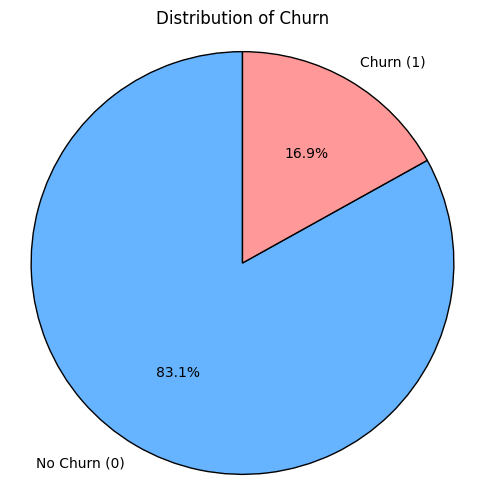

In [21]:
# Calculate the distribution of the 'Churn' target variable
churn_distribution = y_train.value_counts()

# Define labels for the pie chart
labels = ['No Churn (0)', 'Churn (1)']
colors = ['#66b3ff', '#ff9999']

# Create the pie chart
plt.figure(figsize=(6, 6))
plt.pie(churn_distribution, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Churn')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [22]:
# from imblearn.over_sampling import SMOTENC

# print("Original Churn distribution:")
# print(y_train.value_counts())

# Identify categorical features for SMOTENC
# categorical_feature_names = [
 #   'CityTier', 'NumberOfDeviceRegistered', 'SatisfactionScore', 'NumberOfAddress', 'Complain',
  #  'Gender_Male', 'PreferredPaymentMode_Credit Card', 'PreferredPaymentMode_E wallet',
  #  'PreferredLoginDevice_Mobile Phone', 'PreferedOrderCat_Grocery',
  #  'PreferedOrderCat_Laptop & Accessory', 'PreferedOrderCat_Mobile',
   # 'MaritalStatus_Married', 'MaritalStatus_Single']

# Initialize SMOTENC
#smote = SMOTENC(categorical_features=categorical_feature_names, random_state=42)

# Apply SMOTENC to the training data
#X_train, y_train = smote.fit_resample(X_train, y_train)

#print("\nResampled Churn distribution:")
#print(y_train.value_counts())

#print(f"\nOriginal dataset shape (before SMOTENC): {X_full.shape}")
#print(f"Resampled dataset shape (after SMOTENC): {X_train.shape}")

In [23]:
X_train = X_train.drop(columns=['CustomerID'], errors='ignore')
X_test = X_test.drop(columns=['CustomerID'], errors='ignore')

print(f"'CustomerID' dropped from X_train. New shape: {X_train.shape}")
print(f"'CustomerID' dropped from X_test. New shape: {X_test.shape}")

'CustomerID' dropped from X_train. New shape: (4502, 14)
'CustomerID' dropped from X_test. New shape: (1126, 14)


# Hyperparameter Tuning

In [24]:
negative_cases = y_train.value_counts()[0]  # Count of retained customers (Churn = 0)
positive_cases = y_train.value_counts()[1]  # Count of churned customers (Churn = 1)

ratio = negative_cases / positive_cases

print(f"Ratio of Retained Customers to Churned Customers: {ratio:.2f}")

Ratio of Retained Customers to Churned Customers: 4.91


In [25]:
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [100, 150, 200],         # Lowered max trees to prevent memorization
    'learning_rate': [0.01, 0.03, 0.05],     # Dropped 0.1 completely to force slower learning
    'max_depth': [2, 3],                     # Severely restrict depth so trees remain simple stumps
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'reg_alpha': [5.0, 10.0, 15.0],          # Heavily increased L1 penalty to kill noisy features
    'reg_lambda': [10.0, 20.0, 50.0],        # Heavily increased L2 penalty to smooth out weights
    'scale_pos_weight': [4.0, 4.91]
}

# 3. Initialize the base estimator
xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

# 4. Set up RandomizedSearchCV optimizing for F1-score
xgb_tuning = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,           # Slightly increased iterations to explore regularization space
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Regularized Hyperparameter Tuning...")
xgb_tuning.fit(X_train, y_train)

best_xgb_model = xgb_tuning.best_estimator_

print("\n--- Tuning Complete ---")
print("Best Regularized Parameters Found:", xgb_tuning.best_params_)

best_index = xgb_tuning.best_index_
print(f"Mean CV F1-Score: {xgb_tuning.cv_results_['mean_test_score'][best_index]:.4f}")

Starting Regularized Hyperparameter Tuning...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

--- Tuning Complete ---
Best Regularized Parameters Found: {'subsample': 0.7, 'scale_pos_weight': 4.0, 'reg_lambda': 20.0, 'reg_alpha': 10.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Mean CV F1-Score: 0.6738


# TRAIN

Optimal threshold found on training set to maximize F1-score: 0.6269

--- XGBoost Model Evaluation (Optimized Model with Optimal Threshold) ---
Training F1-Score (Optimal Threshold): 0.7429  <-- Check for overfitting here
Test F1-Score (Optimal Threshold):     0.7292
--------------------------------------------------
Accuracy: 0.9076
Precision: 0.7035
Recall (Sensitivity): 0.7568
F1-Score: 0.7292
ROC AUC: 0.9256
PR-AUC: 0.7836

--- Confusion Matrix ---


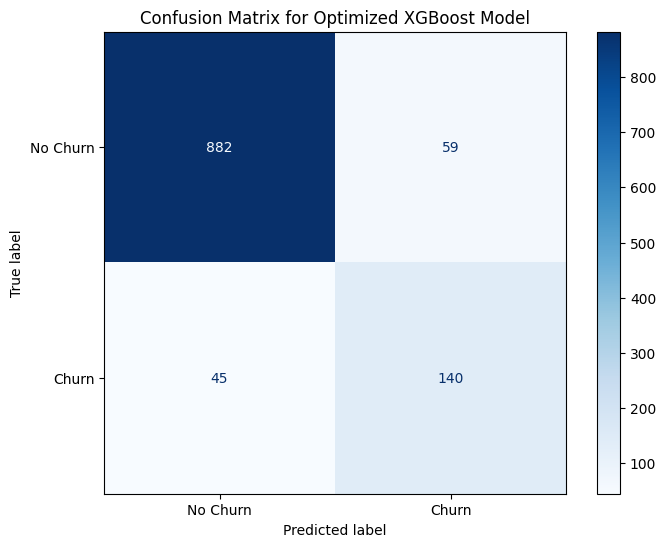

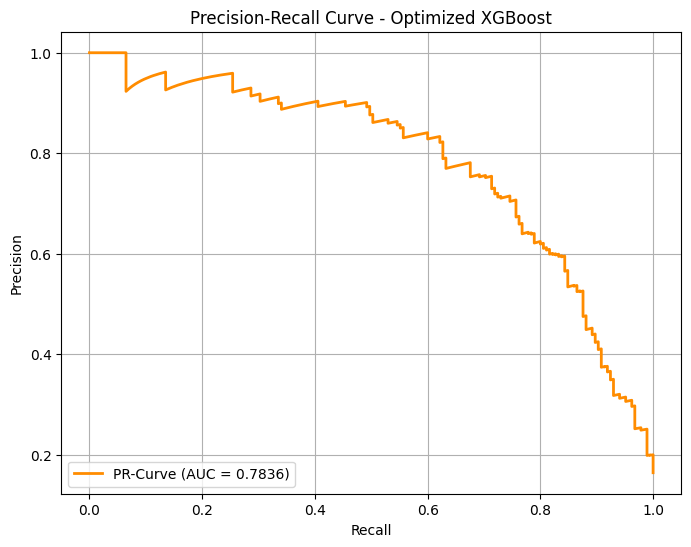

In [26]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, auc, precision_recall_curve,
                             confusion_matrix, ConfusionMatrixDisplay)
import numpy as np
import matplotlib.pyplot as plt

# 1. Make predictions on Train and Test sets using the optimized model
y_train_pred_proba = best_xgb_model.predict_proba(X_train)[:, 1]
y_pred_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# 2. Find optimal threshold to maximize F1-score on the training set
# This ensures the threshold is optimized on the data the model was trained on
precision_train, recall_train, thresholds_train = precision_recall_curve(y_train, y_train_pred_proba)

f_scores_train = 2 * (precision_train * recall_train) / (precision_train + recall_train)
# Replace NaN (due to 0/0) with 0
f_scores_train = np.nan_to_num(f_scores_train, nan=0.0)

optimal_threshold_idx = np.argmax(f_scores_train)
optimal_threshold = thresholds_train[optimal_threshold_idx]

print(f"Optimal threshold found on training set to maximize F1-score: {optimal_threshold:.4f}")

# Apply optimal threshold to make predictions
y_train_pred_optimal = (y_train_pred_proba >= optimal_threshold).astype(int)
y_pred_xgb_optimal = (y_pred_proba_xgb >= optimal_threshold).astype(int)

# 3. Overfitting Check: Compare Train F1 vs Test F1 using optimal threshold
f1_train_optimal = f1_score(y_train, y_train_pred_optimal)
f1_test_optimal = f1_score(y_test, y_pred_xgb_optimal)

# 4. Calculate evaluation metrics on the Test set using optimal threshold
accuracy_xgb = accuracy_score(y_test, y_pred_xgb_optimal)
precision_xgb = precision_score(y_test, y_pred_xgb_optimal)
recall_xgb = recall_score(y_test, y_pred_xgb_optimal)
f1_xgb = f1_score(y_test, y_pred_xgb_optimal)
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)

# 5. Calculate PR-AUC
precision_curve_xgb, recall_curve_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc_xgb = auc(recall_curve_xgb, precision_curve_xgb)

# 6. Print Evaluation Summary
print("\n--- XGBoost Model Evaluation (Optimized Model with Optimal Threshold) ---")
print(f"Training F1-Score (Optimal Threshold): {f1_train_optimal:.4f}  <-- Check for overfitting here")
print(f"Test F1-Score (Optimal Threshold):     {f1_test_optimal:.4f}")
print("-" * 50)
print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall (Sensitivity): {recall_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print(f"ROC AUC: {roc_auc_xgb:.4f}")
print(f"PR-AUC: {pr_auc_xgb:.4f}")

# 7. Plot Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_xgb_optimal)
fig, ax = plt.subplots(figsize=(8, 6))
cmd = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
cmd.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix for Optimized XGBoost Model')
plt.grid(False) # Turn off grid for confusion matrix
plt.show()

# 8. Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall_curve_xgb, precision_curve_xgb, label=f'PR-Curve (AUC = {pr_auc_xgb:.4f})', color='darkorange', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Optimized XGBoost')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()